In [9]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from assistant_probing.axis_download import download_axis, load_axis
import matplotlib.pyplot as plt
import numpy as np
import shutil
import torch

In [10]:
# --- configure paths here ---
AXIS_DIR = Path.cwd() / "data" / "axis"
PROBE_DIR = Path.cwd() / "data" / "probe"
ROLE_VECTORS_DIR = PROBE_DIR / "role_vectors"
DEFAULT_VECTOR_PATH = PROBE_DIR / "default_vector.pt"
MODEL_ID = "Qwen/Qwen3-32B"
LAYER = 32
# ----------------------------

In [11]:
# --- download role vectors if not present ---
if not ROLE_VECTORS_DIR.exists() or not any(ROLE_VECTORS_DIR.glob("*.pt")):
    print("downloading role vectors from HuggingFace...")
    from huggingface_hub import snapshot_download
    snapshot_dir = Path(snapshot_download(
        repo_id="lu-christina/assistant-axis-vectors",
        repo_type="dataset",
        allow_patterns=["qwen-3-32b/role_vectors/*.pt", "qwen-3-32b/default_vector.pt"],
    ))
    ROLE_VECTORS_DIR.mkdir(parents=True, exist_ok=True)
    for src in sorted((snapshot_dir / "qwen-3-32b" / "role_vectors").glob("*.pt")):
        dst = ROLE_VECTORS_DIR / src.name
        if not dst.exists():
            shutil.copy(src, dst)
    src_default = snapshot_dir / "qwen-3-32b" / "default_vector.pt"
    if not DEFAULT_VECTOR_PATH.exists():
        shutil.copy(src_default, DEFAULT_VECTOR_PATH)
    print(f"downloaded {len(list(ROLE_VECTORS_DIR.glob('*.pt')))} role vectors")
else:
    print(f"found {len(list(ROLE_VECTORS_DIR.glob('*.pt')))} role vectors locally")

downloading role vectors from HuggingFace...


Fetching ... files: 0it [00:00, ?it/s]

c:\Users\THINKPAD T14\anaconda3\envs\May2026Projects\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\THINKPAD T14\.cache\huggingface\hub\datasets--lu-christina--assistant-axis-vectors. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


downloaded 275 role vectors


In [13]:
# --- load axis ---
axis = load_axis(download_axis(MODEL_ID, AXIS_DIR))
axis_vec = axis[LAYER].float().numpy()
axis_vec = axis_vec / np.linalg.norm(axis_vec)

In [14]:
# --- build dataset ---
def _load_vec(path, layer):
    data = torch.load(path, map_location="cpu", weights_only=False)
    if isinstance(data, dict):
        return data["axis"][layer].float().numpy()
    return data[layer].float().numpy()

vectors, labels, names = [], [], []

for path in sorted(ROLE_VECTORS_DIR.glob("*.pt")):
    vectors.append(_load_vec(path, LAYER))
    labels.append(0)
    names.append(path.stem)

vectors.append(_load_vec(DEFAULT_VECTOR_PATH, LAYER))
labels.append(1)
names.append("default_assistant")

X = np.stack(vectors)
y = np.array(labels, dtype=np.int64)
print(f"dataset: {X.shape[0]} vectors ({int(y.sum())} assistant, {int((y==0).sum())} role)")

dataset: 276 vectors (1 assistant, 275 role)


In [15]:
# --- project onto axis ---
projections = X @ axis_vec

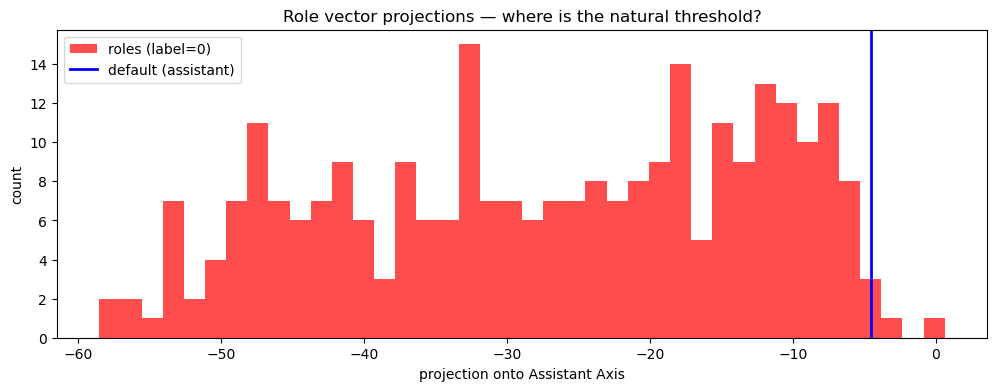

In [16]:
# --- plot distribution ---
plt.figure(figsize=(12, 4))
plt.hist(projections[y == 0], bins=40, alpha=0.7, label="roles (label=0)", color="red")
plt.axvline(projections[y == 1][0], color="blue", linewidth=2, label="default (assistant)")
plt.xlabel("projection onto Assistant Axis")
plt.ylabel("count")
plt.title("Role vector projections — where is the natural threshold?")
plt.legend()
plt.show()

In [17]:
# --- top and bottom 10 ---
sorted_idx = np.argsort(projections)
print("MOST non-assistant (lowest projection):")
for i in sorted_idx[:10]:
    print(f"  {projections[i]: .4f}  {names[i]}")

print("\nMOST assistant-like (highest projection):")
for i in sorted_idx[-10:]:
    print(f"  {projections[i]: .4f}  {names[i]}")

print(f"\ndefault vector projection: {projections[y==1][0]:.4f}")
print(f"role vector median:        {np.median(projections[y==0]):.4f}")
print(f"role vector mean:          {np.mean(projections[y==0]):.4f}")

MOST non-assistant (lowest projection):
  -58.4995  leviathan
  -57.2705  eldritch
  -55.9306  aberration
  -55.5624  wraith
  -55.1409  void
  -54.0117  demon
  -53.7306  vampire
  -53.5873  prophet
  -53.1395  echo
  -52.8526  bard

MOST assistant-like (highest projection):
  -5.9072  consultant
  -5.6577  analyst
  -5.3452  doctor
  -5.3199  lawyer
  -5.2690  researcher
  -4.8537  supervisor
  -4.5442  default_assistant
  -4.0923  validator
  -3.4601  assistant
   0.6314  summarizer

default vector projection: -4.5442
role vector median:        -25.8559
role vector mean:          -27.1437


In [19]:
import pandas as pd
pd.set_option("display.max_rows", None)

df_roles = pd.DataFrame({
    "rank": range(1, len(names)+1),
    "name": [names[i] for i in np.argsort(projections)[::-1]],
    "projection": [projections[i] for i in np.argsort(projections)[::-1]],
    "label": [y[i] for i in np.argsort(projections)[::-1]],
})
df_roles["label"] = df_roles["label"].map({0: "role", 1: "DEFAULT"})
df_roles

,rank,name,projection,label
0,1,summarizer,0.631356,role
1,2,assistant,-3.460094,role
2,3,validator,-4.092319,role
3,4,default_assistant,-4.544159,DEFAULT
4,5,supervisor,-4.853744,role
5,6,researcher,-5.269048,role
6,7,lawyer,-5.319935,role
7,8,doctor,-5.345178,role
8,9,analyst,-5.657733,role
9,10,consultant,-5.907176,role
